In [23]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.7.1+cpu
False


In [25]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch version: 2.7.1+cpu
Torchvision version: 0.22.1+cpu
CUDA available: False
Using device: cpu


In [26]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))
print("Classes:", train_dataset.classes)

Train dataset size: 50000
Test dataset size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 782
Test batches: 157


Creating the CNN model

In [29]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Create the model object

In [30]:
model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


Define loss and optimizer

In [31]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss and optimizer ready")

Loss and optimizer ready


Add training function

In [32]:
def train_model(model, train_loader, criterion, optimizer, device, epochs=10):
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

Add evaluation function

In [33]:
def evaluate_model(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy


In [36]:
baseline_accuracy = evaluate_model(model, test_loader, device)

Test Accuracy: 75.03%


Train the model

In [35]:
train_model(model, train_loader, criterion, optimizer, device, epochs=10)

Epoch [1/10] - Loss: 1.3966
Epoch [2/10] - Loss: 0.9482
Epoch [3/10] - Loss: 0.7551
Epoch [4/10] - Loss: 0.6297
Epoch [5/10] - Loss: 0.5229
Epoch [6/10] - Loss: 0.4272
Epoch [7/10] - Loss: 0.3412
Epoch [8/10] - Loss: 0.2731
Epoch [9/10] - Loss: 0.2065
Epoch [10/10] - Loss: 0.1680


Save the model

In [37]:
import os

os.makedirs("../checkpoints", exist_ok=True)
torch.save(model.state_dict(), "../checkpoints/cnn_baseline.pth")
print("Model saved successfully.")

Model saved successfully.


Show all Layers

In [38]:
for name, module in model.named_modules():
    print(name, "->", module)

 -> SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
features -> Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, 

the layers that can prune

In [39]:
import torch.nn as nn

for name, module in model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        print("Prunable layer:", name, "| Type:", type(module).__name__)

Prunable layer: features.0 | Type: Conv2d
Prunable layer: features.3 | Type: Conv2d
Prunable layer: features.6 | Type: Conv2d
Prunable layer: classifier.1 | Type: Linear
Prunable layer: classifier.3 | Type: Linear


manual pruning test before RL

Import pruning tools

In [40]:
import copy
import torch.nn.utils.prune as prune

Define pruning function

In [46]:
def apply_global_pruning(model, amount=0.2):
    pruned_model = copy.deepcopy(model)

    parameters_to_prune = []

    for module in pruned_model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, "weight"))

    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=amount,
    )

    return pruned_model

Create pruned model

In [47]:
pruned_model_20 = apply_global_pruning(model, amount=0.2).to(device)
print("20% pruning applied")

20% pruning applied


Evaluate pruned model

In [48]:
accuracy_20 = evaluate_model(pruned_model_20, test_loader, device)
print("Accuracy after 20% pruning:", accuracy_20)

Test Accuracy: 75.05%
Accuracy after 20% pruning: 75.05


Define sparsity function

In [43]:
def calculate_sparsity(model):
    total_params = 0
    zero_params = 0

    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight
            total_params += weight.nelement()
            zero_params += torch.sum(weight == 0).item()

    sparsity = 100.0 * zero_params / total_params
    return sparsity

Calculate sparsity

In [44]:
sparsity_20 = calculate_sparsity(pruned_model_20)
print(f"Sparsity after 20% pruning: {sparsity_20:.2f}%")

Sparsity after 20% pruning: 20.00%


Compare baseline vs pruned

In [49]:
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")
print(f"20% Pruned Accuracy: {accuracy_20:.2f}%")
print(f"20% Pruned Sparsity: {sparsity_20:.2f}%")

Baseline Accuracy: 75.03%
20% Pruned Accuracy: 75.05%
20% Pruned Sparsity: 20.00%


In [50]:
pruned_model_40 = apply_global_pruning(model, amount=0.4).to(device)
accuracy_40 = evaluate_model(pruned_model_40, test_loader, device)
sparsity_40 = calculate_sparsity(pruned_model_40)

print(f"40% Pruned Accuracy: {accuracy_40:.2f}%")
print(f"40% Pruned Sparsity: {sparsity_40:.2f}%")

Test Accuracy: 75.17%
40% Pruned Accuracy: 75.17%
40% Pruned Sparsity: 40.00%


In [51]:
pruned_model_60 = apply_global_pruning(model, amount=0.6).to(device)
accuracy_60 = evaluate_model(pruned_model_60, test_loader, device)
sparsity_60 = calculate_sparsity(pruned_model_60)

print(f"60% Pruned Accuracy: {accuracy_60:.2f}%")
print(f"60% Pruned Sparsity: {sparsity_60:.2f}%")

Test Accuracy: 74.92%
60% Pruned Accuracy: 74.92%
60% Pruned Sparsity: 60.00%


In [52]:
import pandas as pd

results_df = pd.DataFrame([
    {"Method": "Baseline", "Accuracy (%)": baseline_accuracy, "Sparsity (%)": 0.0},
    {"Method": "Pruned 20%", "Accuracy (%)": accuracy_20, "Sparsity (%)": sparsity_20},
    {"Method": "Pruned 40%", "Accuracy (%)": accuracy_40, "Sparsity (%)": sparsity_40},
    {"Method": "Pruned 60%", "Accuracy (%)": accuracy_60, "Sparsity (%)": sparsity_60},
])

results_df

,Method,Accuracy (%),Sparsity (%)
0,Baseline,75.03,0.000000
1,Pruned 20%,75.05,19.999935
2,Pruned 40%,75.17,40.000032
3,Pruned 60%,74.92,59.999968


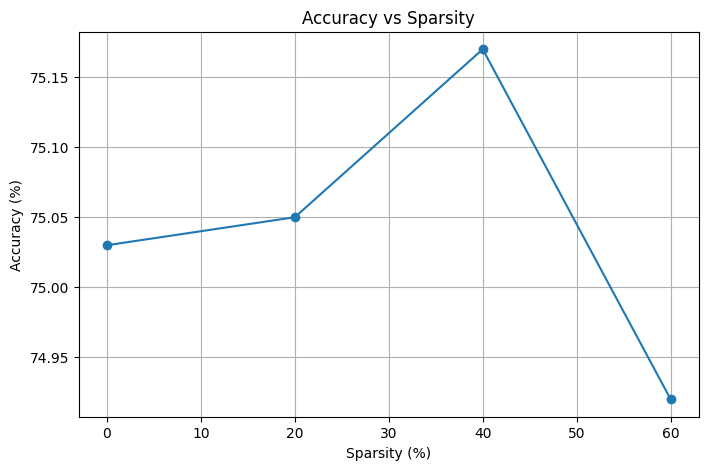

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(results_df["Sparsity (%)"], results_df["Accuracy (%)"], marker="o")
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity")
plt.grid(True)
plt.show()

RL Design v1

State

current layer index
current layer parameter count
current layer mean absolute weight
current layer standard deviation of weights
cumulative pruning so far

Action

0 = prune 0%
1 = prune 10%
2 = prune 20%
3 = prune 30%
4 = prune 40%
5 = prune 50%

Reward

based on final accuracy and compression

extract layer information

In [54]:
def get_prunable_layers(model):
    prunable_layers = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            prunable_layers.append((name, module))

    return prunable_layers

prunable_layers = get_prunable_layers(model)

for i, (name, layer) in enumerate(prunable_layers):
    print(f"Layer {i}: {name} | Type: {type(layer).__name__} | Params: {layer.weight.numel()}")

Layer 0: features.0 | Type: Conv2d | Params: 864
Layer 1: features.3 | Type: Conv2d | Params: 18432
Layer 2: features.6 | Type: Conv2d | Params: 73728
Layer 3: classifier.1 | Type: Linear | Params: 524288
Layer 4: classifier.3 | Type: Linear | Params: 2560


build state features

In [55]:
def extract_layer_state(layer, layer_index, total_layers, cumulative_pruning):
    weights = layer.weight.detach().cpu()

    state = {
        "layer_index": layer_index,
        "total_layers": total_layers,
        "param_count": weights.numel(),
        "mean_abs_weight": weights.abs().mean().item(),
        "std_weight": weights.std().item(),
        "cumulative_pruning": cumulative_pruning,
    }

    return state

test state extraction

In [56]:
total_layers = len(prunable_layers)
cumulative_pruning = 0.0

for i, (name, layer) in enumerate(prunable_layers):
    state = extract_layer_state(layer, i, total_layers, cumulative_pruning)
    print(f"{name} -> {state}")

features.0 -> {'layer_index': 0, 'total_layers': 5, 'param_count': 864, 'mean_abs_weight': 0.13359452784061432, 'std_weight': 0.1607123464345932, 'cumulative_pruning': 0.0}
features.3 -> {'layer_index': 1, 'total_layers': 5, 'param_count': 18432, 'mean_abs_weight': 0.08359380811452866, 'std_weight': 0.10846080631017685, 'cumulative_pruning': 0.0}
features.6 -> {'layer_index': 2, 'total_layers': 5, 'param_count': 73728, 'mean_abs_weight': 0.07593166828155518, 'std_weight': 0.09914207458496094, 'cumulative_pruning': 0.0}
classifier.1 -> {'layer_index': 3, 'total_layers': 5, 'param_count': 524288, 'mean_abs_weight': 0.04153870791196823, 'std_weight': 0.06690666079521179, 'cumulative_pruning': 0.0}
classifier.3 -> {'layer_index': 4, 'total_layers': 5, 'param_count': 2560, 'mean_abs_weight': 0.07070381939411163, 'std_weight': 0.10035252571105957, 'cumulative_pruning': 0.0}


convert state into numeric vector

In [105]:
import numpy as np

def state_to_vector(state):
    return np.array([
        state["layer_index"] / max(1, state["total_layers"] - 1),
        np.log1p(state["param_count"]),
        state["param_count"] / 524288.0,  # normalize by largest layer
        state["mean_abs_weight"],
        state["std_weight"],
        state["cumulative_pruning"],
    ], dtype=np.float32)

Testing it with one layer:

In [106]:
example_state = extract_layer_state(prunable_layers[0][1], 0, len(prunable_layers), 0.0)
example_vector = state_to_vector(example_state)

print("State dict:", example_state)
print("State vector:", example_vector)
print("Vector shape:", example_vector.shape)

State dict: {'layer_index': 0, 'total_layers': 5, 'param_count': 864, 'mean_abs_weight': 0.13359452784061432, 'std_weight': 0.1607123464345932, 'cumulative_pruning': 0.0}
State vector: [0.0000000e+00 6.7627296e+00 1.6479492e-03 1.3359453e-01 1.6071235e-01
 0.0000000e+00]
Vector shape: (6,)


define action mapping

Your RL agent will choose an action number.
We need to translate that number into pruning percentage.

In [59]:
ACTION_TO_PRUNE = {
    0: 0.0,
    1: 0.1,
    2: 0.2,
    3: 0.3,
    4: 0.4,
    5: 0.5,
}

print(ACTION_TO_PRUNE)

{0: 0.0, 1: 0.1, 2: 0.2, 3: 0.3, 4: 0.4, 5: 0.5}


apply pruning to one named layer

Before building the full RL environment, test whether you can prune one chosen layer.

In [81]:
def apply_layer_pruning_by_name_inplace(model, layer_name, amount):
    for name, module in model.named_modules():
        if name == layer_name and isinstance(module, (nn.Conv2d, nn.Linear)):
            prune.l1_unstructured(module, name="weight", amount=amount)
            return model

    raise ValueError(f"Layer {layer_name} not found or not prunable")

Test single-layer pruning on the first layer:

In [61]:
single_pruned_model = apply_layer_pruning_by_name(model, "features.0", 0.3).to(device)
single_pruned_accuracy = evaluate_model(single_pruned_model, test_loader, device)
single_pruned_sparsity = calculate_sparsity(single_pruned_model)

print(f"Single-layer pruned accuracy: {single_pruned_accuracy:.2f}%")
print(f"Single-layer global sparsity: {single_pruned_sparsity:.2f}%")

Test Accuracy: 74.26%
Single-layer pruned accuracy: 74.26%
Single-layer global sparsity: 0.04%


create a tiny environment skeleton

Now we make the first very small environment class.
Not full RL yet — just the logic.

In [69]:
class SimpleCompressionEnv:
    def __init__(self, base_model, prunable_layers, baseline_accuracy, test_loader, device):
        self.base_model = base_model
        self.prunable_layers_info = [(name, type(layer).__name__) for name, layer in prunable_layers]
        self.total_layers = len(prunable_layers)
        self.baseline_accuracy = baseline_accuracy
        self.test_loader = test_loader
        self.device = device
        self.reset()

    def reset(self):
        self.current_layer_index = 0
        self.current_model = copy.deepcopy(self.base_model)
        self.cumulative_pruning = 0.0
        return self._get_state()

    def _get_state(self):
        if self.current_layer_index >= self.total_layers:
            return None

        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        for name, module in self.current_model.named_modules():
            if name == layer_name:
                state = extract_layer_state(
                    module,
                    self.current_layer_index,
                    self.total_layers,
                    self.cumulative_pruning
                )
                return state_to_vector(state)

        raise ValueError(f"Layer {layer_name} not found in current model")

    def step(self, action):
        prune_amount = ACTION_TO_PRUNE[action]
        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        self.current_model = apply_layer_pruning_by_name_inplace(
            self.current_model,
            layer_name,
            prune_amount
        )

        self.cumulative_pruning += prune_amount
        self.current_layer_index += 1

        done = self.current_layer_index >= self.total_layers

        if done:
            final_accuracy = evaluate_model(self.current_model, self.test_loader, self.device)
            final_sparsity = calculate_sparsity(self.current_model)
            reward = compute_reward(final_accuracy, self.baseline_accuracy, final_sparsity)
            next_state = None
            info = {
                "final_accuracy": final_accuracy,
                "final_sparsity": final_sparsity,
                "reward": reward
            }
        else:
            reward = 0.0
            next_state = self._get_state()
            info = {
                "current_layer": layer_name,
                "prune_amount": prune_amount
            }

        return next_state, reward, done, info

test the environment manually

In [71]:
env = SimpleCompressionEnv(
    base_model=model,
    prunable_layers=prunable_layers,
    baseline_accuracy=baseline_accuracy,
    test_loader=test_loader,
    device=device
)

state = env.reset()
print("Initial state:", state)

Initial state: [0.         6.7627296  0.13359453 0.16071235 0.        ]


Add reward and episode-end evaluation

In [ ]:
add a reward function

In [107]:
def compute_reward(compressed_accuracy, baseline_accuracy, sparsity, actions):
    accuracy_ratio = compressed_accuracy / baseline_accuracy
    sparsity_ratio = sparsity / 100.0

    # base reward
    reward = (2.0 * accuracy_ratio) + sparsity_ratio

    # penalty for accuracy drop
    if compressed_accuracy < baseline_accuracy - 2.0:
        reward -= 1.0

    # NEW: diversity bonus
    unique_actions = len(set(actions))
    diversity_bonus = unique_actions * 0.05

    reward += diversity_bonus

    return reward

upgrade the environment

In [109]:
class SimpleCompressionEnv:
    def __init__(self, base_model, prunable_layers, baseline_accuracy, test_loader, device):
        self.base_model = base_model
        self.prunable_layers_info = [(name, type(layer).__name__) for name, layer in prunable_layers]
        self.total_layers = len(prunable_layers)
        self.baseline_accuracy = baseline_accuracy
        self.test_loader = test_loader
        self.device = device
        self.actions_taken = []
        self.reset()

    def reset(self):
        self.current_layer_index = 0
        self.current_model = copy.deepcopy(self.base_model)
        self.cumulative_pruning = 0.0
        self.actions_taken = []
        return self._get_state()

    def _get_state(self):
        if self.current_layer_index >= self.total_layers:
            return None

        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        for name, module in self.current_model.named_modules():
            if name == layer_name:
                state = extract_layer_state(
                    module,
                    self.current_layer_index,
                    self.total_layers,
                    self.cumulative_pruning
                )
                return state_to_vector(state)

        raise ValueError(f"Layer {layer_name} not found in current model")

    def step(self, action):
        prune_amount = ACTION_TO_PRUNE[action]
        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        self.current_model = apply_layer_pruning_by_name_inplace(
            self.current_model,
            layer_name,
            prune_amount,
            self.actions_taken.append(action)
        )

        self.cumulative_pruning += prune_amount
        self.current_layer_index += 1

        done = self.current_layer_index >= self.total_layers

        if done:
            final_accuracy = evaluate_model(self.current_model, self.test_loader, self.device)
            final_sparsity = calculate_sparsity(self.current_model)
            reward = compute_reward(final_accuracy, self.baseline_accuracy, final_sparsity)
            next_state = None
            info = {
                "final_accuracy": final_accuracy,
                "final_sparsity": final_sparsity,
                "reward": reward
            }
        else:
            reward = 0.0
            next_state = self._get_state()
            info = {
                "current_layer": layer_name,
                "prune_amount": prune_amount
            }

        return next_state, reward, done, info

create the upgraded environment

In [83]:
env = SimpleCompressionEnv(
    base_model=model,
    prunable_layers=prunable_layers,
    baseline_accuracy=baseline_accuracy,
    test_loader=test_loader,
    device=device
)

state = env.reset()
print("Initial state:", state)

Initial state: [0.         6.7627296  0.13359453 0.16071235 0.        ]


manually simulate one full episode

In [84]:
state = env.reset()

actions = [2, 2, 2, 2, 2]  # prune 20% on every prunable layer

for step_idx, action in enumerate(actions):
    next_state, reward, done, info = env.step(action)

    print(f"Step {step_idx + 1}")
    print("Action:", action, "-> Prune amount:", ACTION_TO_PRUNE[action])
    print("Done:", done)
    print("Reward:", reward)
    print("Info:", info)
    print("-" * 40)

    if done:
        break

Step 1
Action: 2 -> Prune amount: 0.2
Done: False
Reward: 0.0
Info: {'current_layer': 'features.0', 'prune_amount': 0.2}
----------------------------------------
Step 2
Action: 2 -> Prune amount: 0.2
Done: False
Reward: 0.0
Info: {'current_layer': 'features.3', 'prune_amount': 0.2}
----------------------------------------
Step 3
Action: 2 -> Prune amount: 0.2
Done: False
Reward: 0.0
Info: {'current_layer': 'features.6', 'prune_amount': 0.2}
----------------------------------------
Step 4
Action: 2 -> Prune amount: 0.2
Done: False
Reward: 0.0
Info: {'current_layer': 'classifier.1', 'prune_amount': 0.2}
----------------------------------------
Test Accuracy: 74.31%
Step 5
Action: 2 -> Prune amount: 0.2
Done: True
Reward: 2.180808644870997
Info: {'final_accuracy': 74.31, 'final_sparsity': 20.000096794176862, 'reward': 2.180808644870997}
----------------------------------------


test different action policies

In [85]:
def run_policy(env, actions, policy_name="Policy"):
    state = env.reset()

    for action in actions:
        next_state, reward, done, info = env.step(action)
        if done:
            print(f"{policy_name} Results:")
            print(info)
            return info

In [86]:
policy_1 = [0, 0, 0, 0, 0]  # no pruning
policy_2 = [2, 2, 2, 2, 2]  # all 20%
policy_3 = [5, 5, 5, 5, 5]  # all 50%
policy_4 = [0, 1, 2, 3, 4]  # mixed

run_policy(env, policy_1, "No Pruning Policy")
run_policy(env, policy_2, "Uniform 20% Policy")
run_policy(env, policy_3, "Uniform 50% Policy")
run_policy(env, policy_4, "Mixed Policy")

Test Accuracy: 75.03%
No Pruning Policy Results:
{'final_accuracy': 75.03, 'final_sparsity': 0.0, 'reward': 2.0}
Test Accuracy: 74.31%
Uniform 20% Policy Results:
{'final_accuracy': 74.31, 'final_sparsity': 20.000096794176862, 'reward': 2.180808644870997}
Test Accuracy: 60.44%
Uniform 50% Policy Results:
{'final_accuracy': 60.44, 'final_sparsity': 50.0, 'reward': 1.1110888977742235}
Test Accuracy: 75.09%
Mixed Policy Results:
{'final_accuracy': 75.09, 'final_sparsity': 28.215341231738165, 'reward': 2.2837527725732794}


{'final_accuracy': 75.09,
 'final_sparsity': 28.215341231738165,
 'reward': 2.2837527725732794}

import Gymnasium

In [87]:
import gymnasium as gym
from gymnasium import spaces

create a Gym-compatible environment

In [117]:
class CompressionEnvGym(gym.Env):
    def __init__(self, base_model, prunable_layers, baseline_accuracy, test_loader, device):
        super().__init__()

        self.base_model = base_model
        self.prunable_layers_info = [(name, type(layer).__name__) for name, layer in prunable_layers]
        self.total_layers = len(prunable_layers)
        self.baseline_accuracy = baseline_accuracy
        self.test_loader = test_loader
        self.device = device

        self.action_space = spaces.Discrete(len(ACTION_TO_PRUNE))
        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(6,),
            dtype=np.float32
        )

        self.current_layer_index = 0
        self.current_model = None
        self.cumulative_pruning = 0.0
        self.actions_taken = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_layer_index = 0
        self.current_model = copy.deepcopy(self.base_model)
        self.cumulative_pruning = 0.0
        self.actions_taken = []

        observation = self._get_state()
        info = {}

        return observation, info

    def _get_state(self):
        if self.current_layer_index >= self.total_layers:
            return np.zeros((6,), dtype=np.float32)

        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        for name, module in self.current_model.named_modules():
            if name == layer_name:
                state = extract_layer_state(
                    module,
                    self.current_layer_index,
                    self.total_layers,
                    self.cumulative_pruning
                )
                return state_to_vector(state)

        raise ValueError(f"Layer {layer_name} not found in current model")

    def step(self, action):
        prune_amount = ACTION_TO_PRUNE[int(action)]
        layer_name = self.prunable_layers_info[self.current_layer_index][0]

        self.current_model = apply_layer_pruning_by_name_inplace(
            self.current_model,
            layer_name,
            prune_amount
        )

        self.actions_taken.append(int(action))
        self.cumulative_pruning += prune_amount
        self.current_layer_index += 1

        terminated = self.current_layer_index >= self.total_layers
        truncated = False

        if terminated:
            final_accuracy = evaluate_model_silent(self.current_model, self.test_loader, self.device)
            final_sparsity = calculate_sparsity(self.current_model)
            reward = compute_reward(
                final_accuracy,
                self.baseline_accuracy,
                final_sparsity,
                self.actions_taken
            )
            observation = np.zeros((6,), dtype=np.float32)
            info = {
                "final_accuracy": final_accuracy,
                "final_sparsity": final_sparsity,
                "reward": reward
            }
        else:
            reward = 0.0
            observation = self._get_state()
            info = {
                "current_layer": layer_name,
                "prune_amount": prune_amount
            }

        return observation, reward, terminated, truncated, info

create the Gym environment

In [118]:
gym_env = CompressionEnvGym(
    base_model=model,
    prunable_layers=prunable_layers,
    baseline_accuracy=baseline_accuracy,
    test_loader=test_loader,
    device=device
)

test reset

In [119]:
obs, info = gym_env.reset()
print("Initial observation:", obs)
print("Info:", info)
print("Observation shape:", obs.shape)

Initial observation: [0.0000000e+00 6.7627296e+00 1.6479492e-03 1.3359453e-01 1.6071235e-01
 0.0000000e+00]
Info: {}
Observation shape: (6,)


test one step

In [91]:
obs, reward, terminated, truncated, info = gym_env.step(2)

print("Observation:", obs)
print("Reward:", reward)
print("Terminated:", terminated)
print("Truncated:", truncated)
print("Info:", info)

Observation: [0.25       9.8218975  0.08359381 0.10846081 0.2       ]
Reward: 0.0
Terminated: False
Truncated: False
Info: {'current_layer': 'features.0', 'prune_amount': 0.2}


test one full episode in Gym style

In [92]:
obs, info = gym_env.reset()

actions = [2, 2, 2, 2, 2]

for step_idx, action in enumerate(actions):
    obs, reward, terminated, truncated, info = gym_env.step(action)

    print(f"Step {step_idx + 1}")
    print("Action:", action, "-> Prune amount:", ACTION_TO_PRUNE[action])
    print("Reward:", reward)
    print("Terminated:", terminated)
    print("Truncated:", truncated)
    print("Info:", info)
    print("-" * 40)

    if terminated or truncated:
        break

Step 1
Action: 2 -> Prune amount: 0.2
Reward: 0.0
Terminated: False
Truncated: False
Info: {'current_layer': 'features.0', 'prune_amount': 0.2}
----------------------------------------
Step 2
Action: 2 -> Prune amount: 0.2
Reward: 0.0
Terminated: False
Truncated: False
Info: {'current_layer': 'features.3', 'prune_amount': 0.2}
----------------------------------------
Step 3
Action: 2 -> Prune amount: 0.2
Reward: 0.0
Terminated: False
Truncated: False
Info: {'current_layer': 'features.6', 'prune_amount': 0.2}
----------------------------------------
Step 4
Action: 2 -> Prune amount: 0.2
Reward: 0.0
Terminated: False
Truncated: False
Info: {'current_layer': 'classifier.1', 'prune_amount': 0.2}
----------------------------------------
Test Accuracy: 74.31%
Step 5
Action: 2 -> Prune amount: 0.2
Reward: 2.180808644870997
Terminated: True
Truncated: False
Info: {'final_accuracy': 74.31, 'final_sparsity': 20.000096794176862, 'reward': 2.180808644870997}
---------------------------------------

import PPO tools

In [93]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

check the environment

In [121]:
def evaluate_model_silent(model, data_loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [122]:
check_env(gym_env, warn=True)
print("Environment check passed.")

Environment check passed.


create a fresh training environment

In [95]:
train_env = CompressionEnvGym(
    base_model=model,
    prunable_layers=prunable_layers,
    baseline_accuracy=baseline_accuracy,
    test_loader=test_loader,
    device=device
)

create the PPO model

In [96]:
ppo_model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    learning_rate=0.0003,
    n_steps=64,
    batch_size=32,
    n_epochs=10,
    gamma=0.99
)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


train PPO for the first time

In [97]:
ppo_model.learn(total_timesteps=500)
print("PPO training finished.")

Test Accuracy: 70.97%
Test Accuracy: 74.27%
Test Accuracy: 74.35%
Test Accuracy: 74.25%
Test Accuracy: 74.64%
Test Accuracy: 74.44%
Test Accuracy: 74.44%
Test Accuracy: 74.37%
Test Accuracy: 75.07%
Test Accuracy: 74.27%
Test Accuracy: 70.62%
Test Accuracy: 61.27%
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5        |
|    ep_rew_mean     | 1.91     |
| time/              |          |
|    fps             | 0        |
|    iterations      | 1        |
|    time_elapsed    | 192      |
|    total_timesteps | 64       |
---------------------------------
Test Accuracy: 74.16%
Test Accuracy: 73.82%
Test Accuracy: 61.85%
Test Accuracy: 70.75%
Test Accuracy: 62.01%
Test Accuracy: 61.17%
Test Accuracy: 60.44%
Test Accuracy: 60.44%
Test Accuracy: 73.60%
Test Accuracy: 75.14%
Test Accuracy: 75.10%
Test Accuracy: 74.30%
Test Accuracy: 74.84%
------------------------------------------
| rollout/                |              |
|    ep_len_mean        

test the trained PPO agent manually

In [98]:
test_env = CompressionEnvGym(
    base_model=model,
    prunable_layers=prunable_layers,
    baseline_accuracy=baseline_accuracy,
    test_loader=test_loader,
    device=device
)

obs, info = test_env.reset()
done = False

chosen_actions = []

while not done:
    action, _states = ppo_model.predict(obs, deterministic=True)
    chosen_actions.append(int(action))

    obs, reward, terminated, truncated, info = test_env.step(action)
    done = terminated or truncated

print("Chosen actions:", chosen_actions)
print("Final info:", info)

Test Accuracy: 74.59%
Chosen actions: [3, 3, 3, 3, 3]
Final info: {'final_accuracy': 74.59, 'final_sparsity': 29.999903205823138, 'reward': 2.2882703901816486}


compare PPO result with manual policies

In [99]:
ppo_result = info

comparison_df = pd.DataFrame([
    {"Method": "No Pruning", "Accuracy (%)": 75.03, "Sparsity (%)": 0.0, "Reward": 2.0},
    {"Method": "Uniform 20%", "Accuracy (%)": 74.31, "Sparsity (%)": 20.0001, "Reward": 2.1808},
    {"Method": "Uniform 50%", "Accuracy (%)": 60.44, "Sparsity (%)": 50.0, "Reward": 1.1111},
    {"Method": "Mixed Policy", "Accuracy (%)": 75.09, "Sparsity (%)": 28.2153, "Reward": 2.2838},
    {"Method": "PPO Learned Policy", "Accuracy (%)": ppo_result["final_accuracy"], "Sparsity (%)": ppo_result["final_sparsity"], "Reward": ppo_result["reward"]},
])

comparison_df

,Method,Accuracy (%),Sparsity (%),Reward
0,No Pruning,75.03,0.000000,2.00000
1,Uniform 20%,74.31,20.000100,2.18080
2,Uniform 50%,60.44,50.000000,1.11110
3,Mixed Policy,75.09,28.215300,2.28380
4,PPO Learned Policy,74.59,29.999903,2.28827


save the PPO model

In [100]:
import os

os.makedirs("../checkpoints", exist_ok=True)
ppo_model.save("../checkpoints/ppo_compression_agent")
print("PPO model saved successfully.")

PPO model saved successfully.


create a reusable evaluation function

In [101]:
def evaluate_trained_agent(agent, env, policy_name="PPO"):
    obs, info = env.reset()
    done = False
    chosen_actions = []

    while not done:
        action, _states = agent.predict(obs, deterministic=True)
        chosen_actions.append(int(action))

        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

    print(f"{policy_name} chosen actions:", chosen_actions)
    print(f"{policy_name} final info:", info)

    return {
        "policy_name": policy_name,
        "actions": chosen_actions,
        "final_accuracy": info["final_accuracy"],
        "final_sparsity": info["final_sparsity"],
        "reward": info["reward"]
    }

In [123]:
from torch.utils.data import Subset

small_val_indices = list(range(2000))
small_val_dataset = Subset(test_dataset, small_val_indices)

small_val_loader = DataLoader(
    small_val_dataset,
    batch_size=64,
    shuffle=False
)

print("Small validation size:", len(small_val_dataset))

Small validation size: 2000


train multiple PPO runs

In [124]:
ppo_results = []

timesteps_list = [500, 1000]

for timesteps in timesteps_list:
    print(f"\nTraining PPO with total_timesteps={timesteps}")

    train_env = CompressionEnvGym(
        base_model=model,
        prunable_layers=prunable_layers,
        baseline_accuracy=baseline_accuracy,
        test_loader=small_val_loader,
        device=device
    )

    agent = PPO(
        policy="MlpPolicy",
        env=train_env,
        verbose=0,
        learning_rate=0.0003,
        n_steps=64,
        batch_size=32,
        n_epochs=10,
        gamma=0.99
    )

    agent.learn(total_timesteps=timesteps)

    eval_env = CompressionEnvGym(
        base_model=model,
        prunable_layers=prunable_layers,
        baseline_accuracy=baseline_accuracy,
        test_loader=test_loader,
        device=device
    )

    result = evaluate_trained_agent(agent, eval_env, policy_name=f"PPO_{timesteps}")
    result["timesteps"] = timesteps
    ppo_results.append(result)


Training PPO with total_timesteps=500
PPO_500 chosen actions: [2, 2, 2, 2, 2]
PPO_500 final info: {'final_accuracy': 74.31, 'final_sparsity': 20.000096794176862, 'reward': 2.2308086448709967}

Training PPO with total_timesteps=1000
PPO_1000 chosen actions: [3, 3, 3, 3, 3]
PPO_1000 final info: {'final_accuracy': 74.59, 'final_sparsity': 29.999903205823138, 'reward': 2.3382703901816484}


results table

In [125]:
ppo_results_df = pd.DataFrame([
    {
        "Policy": r["policy_name"],
        "Timesteps": r["timesteps"],
        "Actions": str(r["actions"]),
        "Accuracy (%)": r["final_accuracy"],
        "Sparsity (%)": r["final_sparsity"],
        "Reward": r["reward"]
    }
    for r in ppo_results
])

ppo_results_df

,Policy,Timesteps,Actions,Accuracy (%),Sparsity (%),Reward
0,PPO_500,500,"[2, 2, 2, 2, 2]",74.31,20.000097,2.230809
1,PPO_1000,1000,"[3, 3, 3, 3, 3]",74.59,29.999903,2.338270


combine with manual baselines

In [104]:
manual_and_rl_df = pd.DataFrame([
    {"Method": "No Pruning", "Actions": "-", "Accuracy (%)": 75.03, "Sparsity (%)": 0.0, "Reward": 2.0000},
    {"Method": "Uniform 20%", "Actions": "[2,2,2,2,2]", "Accuracy (%)": 74.31, "Sparsity (%)": 20.0001, "Reward": 2.1808},
    {"Method": "Uniform 50%", "Actions": "[5,5,5,5,5]", "Accuracy (%)": 60.44, "Sparsity (%)": 50.0, "Reward": 1.1111},
    {"Method": "Mixed Policy", "Actions": "[0,1,2,3,4]", "Accuracy (%)": 75.09, "Sparsity (%)": 28.2153, "Reward": 2.2838},
])

for r in ppo_results:
    manual_and_rl_df.loc[len(manual_and_rl_df)] = {
        "Method": r["policy_name"],
        "Actions": str(r["actions"]),
        "Accuracy (%)": r["final_accuracy"],
        "Sparsity (%)": r["final_sparsity"],
        "Reward": r["reward"]
    }

manual_and_rl_df

,Method,Actions,Accuracy (%),Sparsity (%),Reward
0,No Pruning,-,75.03,0.000000,2.000000
1,Uniform 20%,"[2,2,2,2,2]",74.31,20.000100,2.180800
2,Uniform 50%,"[5,5,5,5,5]",60.44,50.000000,1.111100
3,Mixed Policy,"[0,1,2,3,4]",75.09,28.215300,2.283800
4,PPO_500,"[2, 2, 2, 2, 2]",74.31,20.000097,2.180809
5,PPO_1000,"[3, 3, 3, 3, 3]",74.59,29.999903,2.288270
6,PPO_2000,"[3, 3, 3, 3, 3]",74.59,29.999903,2.288270
